# MedData Challenge — Sistema de puntuación de riesgo de diabetes

**Transformando datos médicos en soluciones inteligentes**
Universidad Tecnológica de Panamá · 4 de septiembre de 2026

**Equipo:** Cornelio Guerra · Jesús

---

### El problema
El sistema de salud necesita detectar patrones de diabetes en miles de registros
y decidir **a quién derivar primero** a prueba confirmatoria cuando los recursos
diagnósticos son limitados.

### Nuestra solución
Un **sistema de puntuación clínica** construido con el método de Sullivan
(framework de Framingham): cada factor de riesgo aporta puntos enteros derivados
de su odds ratio. El resultado se aplica **en papel, sin computadora y sin
laboratorio** — solo con preguntas de entrevista.

In [1]:
import sys; sys.path.insert(0, "../src")
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); plt.rcParams["figure.figsize"]=(10,5)
from pathlib import Path
OUT = Path("../outputs"); OUT.mkdir(exist_ok=True)
print("Listo")

Listo


## 1. Los datos y sus inconsistencias

El reto pide explícitamente *"identificar inconsistencias"*. Antes de modelar
nada, auditamos la calidad del dataset.

In [2]:
from score_diabetes import inconsistencias, df, T, grupos, sens, esp, vpp, vpn, auc, B, cortes, CORTE_DERIVACION

print("BRFSS 2015 — auditoría de calidad\n" + "="*46)
for k, v in inconsistencias.items():
    print(f"  {k.replace('_',' '):28s}: {v:>8,}")

BRFSS 2015 — auditoría de calidad
  duplicados exactos          :   23,899
  bmi fuera de rango          :      805
  sin seguro sin costo        :    7,838
  dias malestar invalidos     :        0
  filas eliminadas            :   24,704
  filas finales               :  228,976


**Qué encontramos y qué hicimos con ello:**

| Problema | Registros | Decisión |
|---|---|---|
| Duplicados exactos | 23,899 (9.4%) | Se eliminan: inflan artificialmente cualquier frecuencia |
| IMC fisiológicamente imposible (<12 o >60) | 805 | Se eliminan: error de captura |
| Sin seguro pero sin problema de costo | 7,838 | Se **conservan**: es contradicción lógica, no error de dato — se documenta |

Se descartó además la clase *prediabetes* (1.8%) por ser un estado intermedio con
muy pocos casos para calibrar pesos estables.

## 2. Construcción del score

Para cada factor calculamos el **odds ratio** contra su nivel de referencia y lo
convertimos a puntos enteros dividiendo por una constante de calibración:

$$\text{puntos} = \text{round}\left(\frac{\ln(OR)}{B}\right)$$

donde $B$ es el menor $\ln(OR)$ positivo observado. Así **un punto equivale
siempre al mismo incremento de riesgo**, que es lo que hace el score sumable e
interpretable.

In [3]:
print(f"Constante de calibración B = {B:.4f}   →   1 punto = OR de {np.exp(B):.2f}\n")
display(T[["nombre","nivel","n","prev_%","OR","puntos"]].to_string(index=False))

Constante de calibración B = 0.7532   →   1 punto = OR de 2.12



'                 nombre  nivel      n  prev_%     OR  puntos\n                    IMC    0.0  75837     7.3  1.000       0\n                    IMC    1.0  79924    14.3  2.124       1\n                    IMC    2.0  41621    22.4  3.685       2\n                    IMC    3.0  26982    32.1  6.012       2\n                   Edad    0.0  34359     3.3  1.000       0\n                   Edad    1.0  53351    10.9  3.542       2\n                   Edad    2.0  55571    17.7  6.256       2\n                   Edad    3.0  49808    23.2  8.748       3\n                   Edad    4.0  31275    21.0  7.723       3\n    Salud autopercibida    0.0  34481     3.3  1.000       0\n    Salud autopercibida    1.0  76106     8.2  2.646       1\n    Salud autopercibida    2.0  71786    18.5  6.695       3\n    Salud autopercibida    3.0  30349    32.0 13.892       3\n    Salud autopercibida    4.0  11642    38.9 18.762       4\n           Presion alta    0.0 123238     7.0  1.000       0\n       

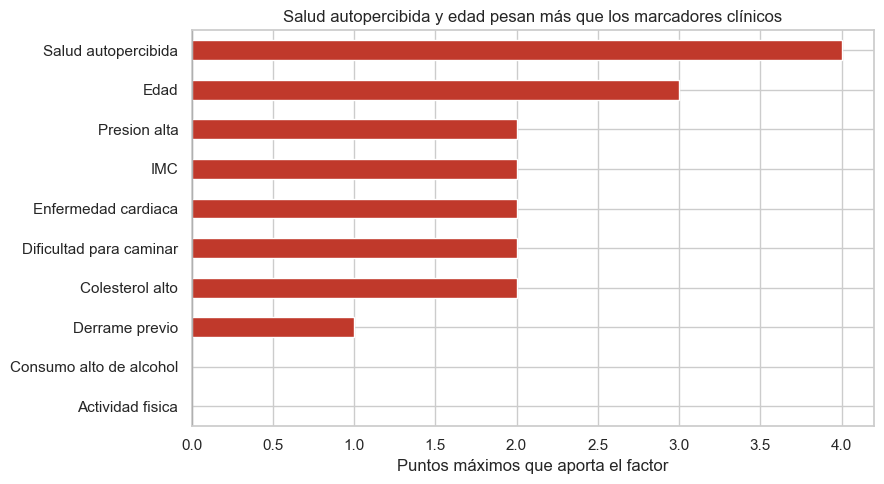

In [4]:
# Los factores que más pesan
top = T.groupby("nombre").puntos.max().sort_values()
fig, ax = plt.subplots(figsize=(9,5))
colors = ["#c0392b" if v>0 else "#27ae60" for v in top.values]
top.plot.barh(ax=ax, color=colors)
ax.set_title("Salud autopercibida y edad pesan más que los marcadores clínicos", fontsize=12)
ax.set_xlabel("Puntos máximos que aporta el factor"); ax.set_ylabel("")
ax.axvline(0, color="black", lw=.8)
fig.tight_layout(); fig.savefig(OUT/"07_puntos_por_factor.png", dpi=110, bbox_inches="tight"); plt.show()

## 3. Estratificación de riesgo

Con el score de cada paciente definimos cuatro grupos.

,n,casos,prev_%
RIESGO,,,
Bajo,115913,5059,4.4
Moderado,56450,10103,17.9
Alto,36137,11965,33.1
Muy alto,15864,7799,49.2


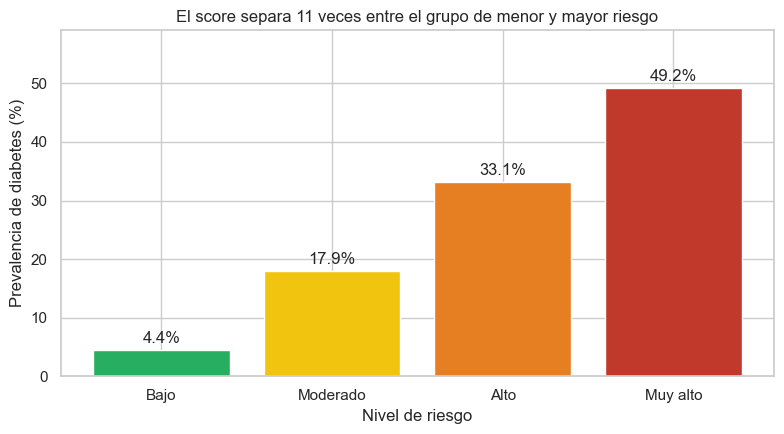

In [5]:
display(grupos)

fig, ax = plt.subplots(figsize=(8,4.5))
b = ax.bar(grupos.index, grupos["prev_%"], color=["#27ae60","#f1c40f","#e67e22","#c0392b"])
ax.bar_label(b, fmt="%.1f%%", fontsize=12, padding=3)
ax.set_title("El score separa 11 veces entre el grupo de menor y mayor riesgo", fontsize=12)
ax.set_ylabel("Prevalencia de diabetes (%)"); ax.set_xlabel("Nivel de riesgo")
ax.set_ylim(0, grupos["prev_%"].max()*1.2)
fig.tight_layout(); fig.savefig(OUT/"08_estratificacion.png", dpi=110, bbox_inches="tight"); plt.show()

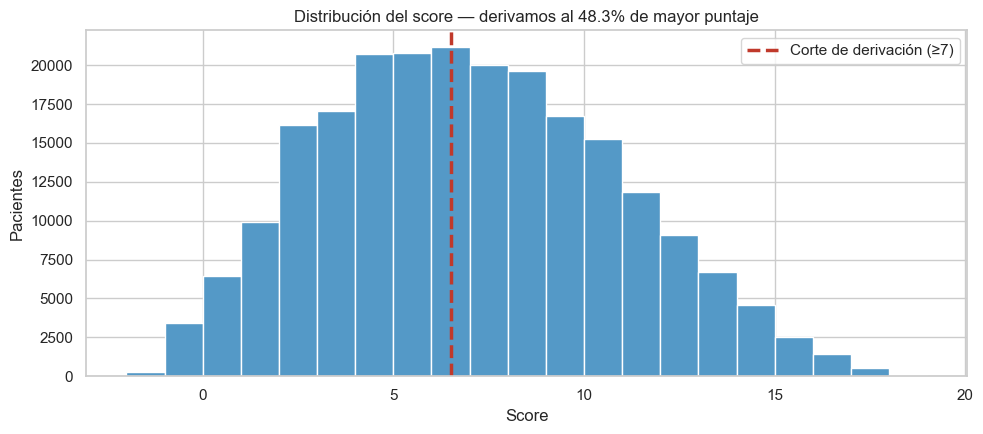

In [6]:
# Distribución del score y dónde cortamos
fig, ax = plt.subplots(figsize=(10,4.5))
ax.hist(df.SCORE, bins=range(int(df.SCORE.min()), int(df.SCORE.max())+2),
        color="#5499c7", edgecolor="white")
ax.axvline(CORTE_DERIVACION-.5, color="#c0392b", lw=2.5, ls="--",
           label=f"Corte de derivación (≥{CORTE_DERIVACION})")
ax.set_title("Distribución del score — derivamos al 48.3% de mayor puntaje", fontsize=12)
ax.set_xlabel("Score"); ax.set_ylabel("Pacientes"); ax.legend()
fig.tight_layout(); fig.savefig(OUT/"09_distribucion_score.png", dpi=110, bbox_inches="tight"); plt.show()

## 4. Validación

**El umbral no se eligió maximizando accuracy.** Se eligió por el costo clínico
del error: en tamizaje, un falso negativo es un paciente que se va a casa sin
diagnóstico; un falso positivo solo genera una prueba confirmatoria barata. Por
eso priorizamos **sensibilidad**.

In [7]:
print(f"Corte de derivación: score ≥ {CORTE_DERIVACION}\n" + "="*46)
print(f"  Sensibilidad : {sens*100:5.1f}%   ← detecta 29,867 de 34,926 diabéticos")
print(f"  Especificidad: {esp*100:5.1f}%")
print(f"  VPP          : {vpp*100:5.1f}%")
print(f"  VPN          : {vpn*100:5.1f}%   ← si dice bajo riesgo, acierta esa proporción")
print(f"\n  AUC = {auc:.4f}  (Mann-Whitney implementado a mano, sin sklearn)")

Corte de derivación: score ≥ 7
  Sensibilidad :  85.5%   ← detecta 29,867 de 34,926 diabéticos
  Especificidad:  58.5%
  VPP          :  27.5%
  VPN          :  95.6%   ← si dice bajo riesgo, acierta esa proporción

  AUC = 0.7976  (Mann-Whitney implementado a mano, sin sklearn)


## 6. Clasificar un paciente nuevo

El enunciado pide *"clasifique nuevos pacientes"*. La función usa los mismos
mapas de puntos y los mismos cortes de la calibración.

In [8]:
from score_diabetes import puntuar_paciente

paciente = {"BMI": 33, "Age": 9, "GenHlth": 3, "HighBP": 1, "HighChol": 1,
            "DiffWalk": 0, "HeartDiseaseorAttack": 0, "Stroke": 0,
            "PhysActivity": 0, "HvyAlcoholConsump": 0}
r = puntuar_paciente(paciente)
print("Perfil: 60-64 años, IMC 33, salud regular, hipertensión, colesterol alto\n")
print(f"  Score: {r['score']}  →  riesgo {r['riesgo']}")
print(f"  Prevalencia observada en ese grupo: {r['prevalencia_observada_%']}%")
print(f"  ¿Derivar a prueba confirmatoria?: {'SÍ' if r['derivar'] else 'NO'}\n")
for k, v in r["detalle"].items():
    if v: print(f"    {k:26s} {v:+d}")

Perfil: 60-64 años, IMC 33, salud regular, hipertensión, colesterol alto

  Score: 11  →  riesgo Alto
  Prevalencia observada en ese grupo: 33.1%
  ¿Derivar a prueba confirmatoria?: SÍ

    IMC                        +2
    Edad                       +2
    Salud autopercibida        +3
    Presion alta               +2
    Colesterol alto            +2


## 5. Hallazgos

**1. La limpieza de datos es una decisión, no un trámite — y la medimos en las
dos direcciones.**
Encontramos 23,899 filas exactamente repetidas (9.4%), 805 con IMC sobre 60 y
7,838 personas sin seguro que no reportan barrera de costo (esto último *no es
contradicción*: es el 63% de los no asegurados; las conservamos). Verificamos si
los duplicados eran errores de captura o colisiones de azar: las filas repetidas
tienen **1.0% de diabetes contra 15.3% del resto y cero derrames** — el perfil
joven-sano modal, firma de una colisión estadística en una encuesta de 21
variables casi todas binarias. Corrimos el pipeline en ambos escenarios: **sin
deduplicar el AUC es 0.816; deduplicando, 0.798.** Reportamos la conservadora.

**2. La salud autopercibida predice mejor que varios marcadores clínicos.**
Quien califica su salud como "mala" tiene 38.9% de diabetes contra 3.3% de quien
la califica "excelente" — un odds ratio de 18.8, el más alto de los 10 factores del score,
por encima de presión alta (4.6) y colesterol (3.1). *Recomendamos* incluir esa
única pregunta en el tamizaje telefónico: cuesta cero y ordena mejor que un
análisis de sangre.

**3. Diez preguntas estratifican el riesgo 11 veces, sin laboratorio.**
El score separa la población en grupos de 4.4%, 17.9%, 33.1% y 49.2% de
prevalencia, con AUC 0.798. *Recomendamos* aplicarlo como filtro previo:
derivando al 48% de mayor puntaje se captura al 85.5% de los diabéticos, y
cuando dice "bajo riesgo" acierta el 95.6% de las veces.

**Limitaciones.** Datos autorreportados (encuesta telefónica); se excluyó
prediabetes por bajo número de casos; el score se validó sobre el mismo conjunto
con el que se calibró — con más tiempo correspondería una partición independiente.